In [1]:
import sys
sys.path.append('C:/Users/Lenovo/Desktop/2019_ICM_E/tools/')
from PPPM import PPPM_datasets
from load_array import LoadArray
from mxnet import autograd,gluon,init
from animator import Animator

In [2]:
PPPM_data = PPPM_datasets(1000)

In [3]:
batch_size = 5
data_loader = LoadArray(PPPM_data,batch_size)

In [4]:
model = gluon.nn.Sequential()
model.add(
    gluon.nn.Dense(3),
    #gluon.nn.Dense(3),
    gluon.nn.Dropout(0.1), # 5+1目前看是可以预测的
    gluon.nn.Dense(1)

)
model.initialize(init.Normal(sigma=0.01))

In [5]:
loss_func = gluon.loss.L2Loss()
optimizer = gluon.Trainer(model.collect_params(),'sgd',{'learning_rate':0.0001})

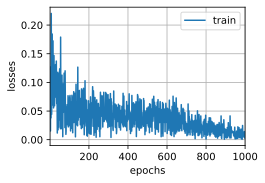

In [6]:
epochs = 1000
animator = Animator(xlabel='epochs',ylabel='losses',legend=['train'],xlim=[1,epochs])
for epoch in range(epochs):
    for feature, label in data_loader:
            with autograd.record():
                l = loss_func(model(feature),label)
                # print(feature,model(feature))
            l.backward()
            optimizer.step(batch_size)
            temp = l.mean().item()
    animator.add(epoch+1, (temp,))
        
                

In [7]:
model[0].weight.data()

array([[ 0.20133406, -0.18882056, -0.12042101, -0.13337633],
       [-0.19606307,  0.17044055,  0.11089918,  0.12550864],
       [-0.23702686,  0.21702962,  0.12022621,  0.16574454]])

In [8]:
from mxnet import np, npx
npx.set_np()
feature = np.array([[0.7922,0.4215,0.8576,0.5833]])
model(feature)

array([[0.45024252]])